# 🎬 Movie Rating Prediction with Python
### CodSoft Data Science Internship – Task 2


## Project Overview
This project predicts movie ratings using machine learning techniques based on features such as Year, Duration, Votes, Genre, Director, and Actors.


## 1. Importing Libraries and Loading the Dataset


In [22]:
uploaded = files.upload()

Saving IMDb Movies India.csv.zip to IMDb Movies India.csv (1).zip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

Saving IMDb Movies India.csv.zip to IMDb Movies India.csv.zip


In [3]:
import zipfile

# Extract the ZIP file
with zipfile.ZipFile("IMDb Movies India.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

# Load the CSV file
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

# Display first 5 rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 2. Dataset Exploration and Data Cleaning


In [4]:
# Dataset information
print("Dataset Information:")
df.info()

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Dataset Shape:
(15509, 10)

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Summary Statistics:
            Rating
count  7919.000000
mean      5.841621
std       1.381777
min       1.100000
25%   

In [5]:
# Remove rows where Rating is missing
df = df.dropna(subset=["Rating"])

# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values after removing missing ratings
print("Missing Values After Removing Missing Ratings:")
print(df.isnull().sum())

# Display cleaned dataset shape
print("\nCleaned Dataset Shape:")
print(df.shape)

# Display first 5 rows
df.head()

Missing Values After Removing Missing Ratings:
Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

Cleaned Dataset Shape:
(7919, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [8]:
# Convert Year from "(2019)" format to numeric
df["Year"] = df["Year"].str.extract(r"(\d{4})").astype(float)

# Convert Duration from "109 min" format to numeric
df["Duration"] = df["Duration"].str.extract(r"(\d+)").astype(float)

# Convert Votes to numeric and remove commas
df["Votes"] = df["Votes"].astype(str).str.replace(",", "", regex=False)
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

# Fill missing numerical values with median
df["Year"] = df["Year"].fillna(df["Year"].median())
df["Duration"] = df["Duration"].fillna(df["Duration"].median())
df["Votes"] = df["Votes"].fillna(df["Votes"].median())

# Fill missing categorical values
df["Genre"] = df["Genre"].fillna("Unknown")
df["Director"] = df["Director"].fillna("Unknown")
df["Actor 1"] = df["Actor 1"].fillna("Unknown")
df["Actor 2"] = df["Actor 2"].fillna("Unknown")
df["Actor 3"] = df["Actor 3"].fillna("Unknown")

# Check final missing values
print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nFinal Dataset Shape:", df.shape)

# Display cleaned data
df.head()

Missing Values After Cleaning:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

Final Dataset Shape: (7919, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997.0,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005.0,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


## 3. Exploratory Data Analysis and Visualization


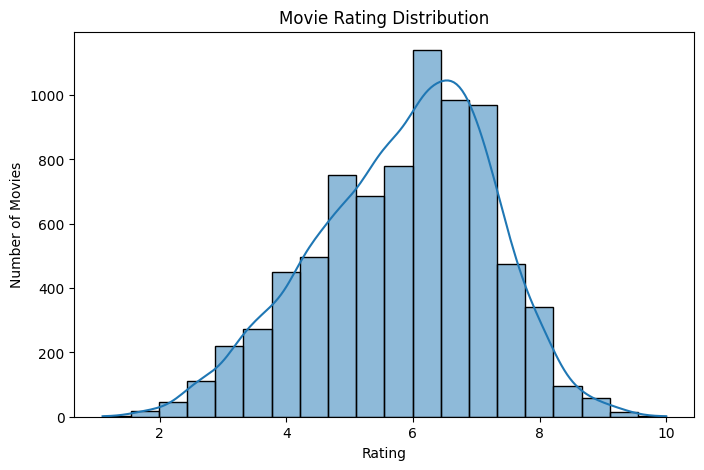

In [9]:
# ================================
# DATA VISUALIZATION
# ================================

# Rating Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

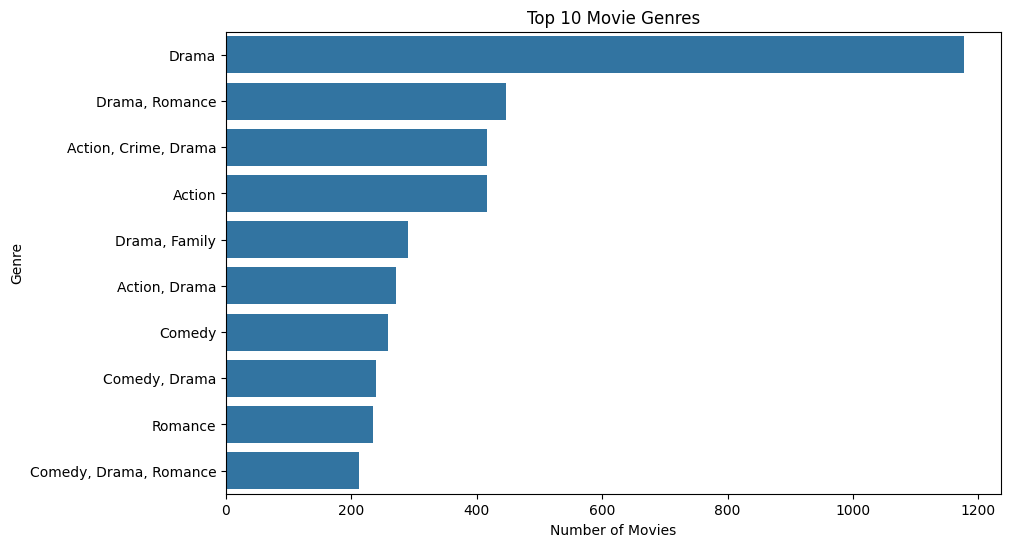

In [10]:
# Top 10 Movie Genres
plt.figure(figsize=(10, 6))

top_genres = df["Genre"].value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

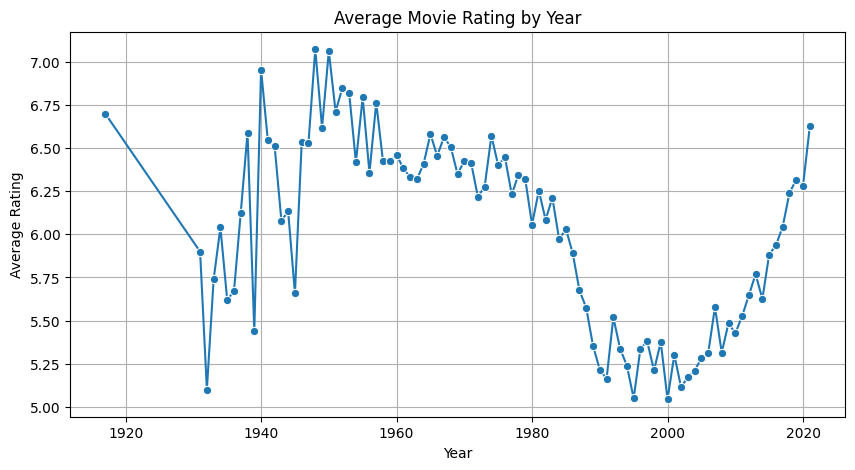

In [11]:
# Average Movie Rating by Year

year_rating = df.groupby("Year")["Rating"].mean().reset_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=year_rating,
    x="Year",
    y="Rating",
    marker="o"
)

plt.title("Average Movie Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid()
plt.show()

## 4. Data Preparation and Model Training


In [12]:
# =====================================
# FEATURE ENGINEERING AND PREPROCESSING
# =====================================

# Create a copy of the dataset
model_df = df.copy()

# Select useful features
features = [
    "Year",
    "Duration",
    "Votes",
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

# Input features
X = model_df[features]

# Target variable
y = model_df["Rating"]

print("Input Features Shape:", X.shape)
print("Target Variable Shape:", y.shape)

print("\nInput Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Features Shape: (7919, 8)
Target Variable Shape: (7919,)

Input Features:
     Year  Duration  Votes                      Genre        Director  \
1  2019.0     109.0      8                      Drama   Gaurav Bakshi   
3  2019.0     110.0     35            Comedy, Romance      Ovais Khan   
5  1997.0     147.0    827     Comedy, Drama, Musical    Rahul Rawail   
6  2005.0     142.0   1086        Drama, Romance, War  Shoojit Sircar   
8  2012.0      82.0    326  Horror, Mystery, Thriller   Allyson Patel   

           Actor 1                 Actor 2          Actor 3  
1     Rasika Dugal          Vivek Ghamande    Arvind Jangid  
3          Prateik              Ishita Raj  Siddhant Kapoor  
5       Bobby Deol  Aishwarya Rai Bachchan    Shammi Kapoor  
6  Jimmy Sheirgill          Minissha Lamba   Yashpal Sharma  
8        Yash Dave          Muntazir Ahmad     Kiran Bhatia  

Target Variable:
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


In [ ]:
# Encode categorical columns

from sklearn.preprocessing import LabelEncoder

# Make an independent copy to avoid SettingWithCopyWarning
X = X.copy()

categorical_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for column in categorical_columns:
    le = LabelEncoder()
    X.loc[:, column] = le.fit_transform(X[column].astype(str))

# Display encoded features
print("Encoded Input Features:")
print(X.head())


In [15]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (6335, 8)
Testing Features Shape: (1584, 8)
Training Target Shape: (6335,)
Testing Target Shape: (1584,)


## 5. Model Evaluation, Feature Importance and Prediction


In [16]:
# Train the Movie Rating Prediction Model

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [17]:
# Make predictions

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict movie ratings
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results:
Mean Absolute Error (MAE): 0.8419015151515152
Mean Squared Error (MSE): 1.2425469381313132
Root Mean Squared Error (RMSE): 1.1146958949109453
R² Score: 0.33165684003462026


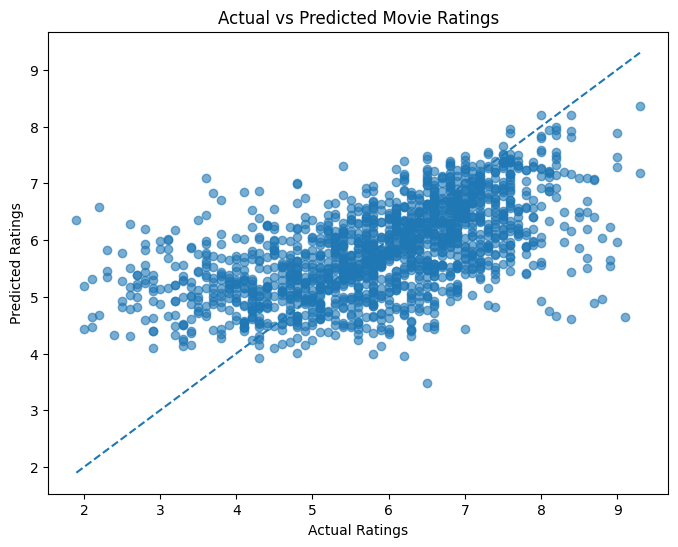

In [18]:
# Visualize Actual vs Predicted Ratings

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")

# Add reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [19]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
    Feature  Importance
2     Votes    0.216606
0      Year    0.201145
3     Genre    0.111166
1  Duration    0.097062
4  Director    0.094153
5   Actor 1    0.094040
6   Actor 2    0.093809
7   Actor 3    0.092019


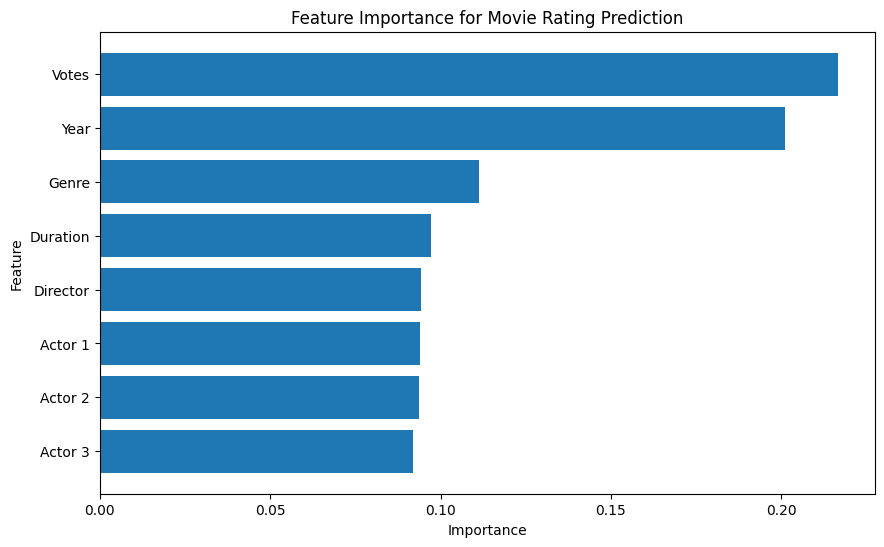

In [20]:
# Visualize Feature Importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Movie Rating Prediction")

plt.gca().invert_yaxis()

plt.show()

In [21]:
# Sample Movie Rating Prediction

sample_movie = X_test.iloc[[0]]

predicted_rating = model.predict(sample_movie)

print("Sample Movie Features:")
print(sample_movie)

print("\nActual Rating:", y_test.iloc[0])
print("Predicted Rating:", predicted_rating[0])

Sample Movie Features:
        Year  Duration  Votes  Genre  Director  Actor 1  Actor 2  Actor 3
9456  1991.0     134.0      6    344      2944      469     1321     1147

Actual Rating: 3.3
Predicted Rating: 4.2589999999999995


## 6. Conclusion
This project demonstrates a complete machine learning workflow including data preprocessing, exploratory data analysis, feature encoding, model training, evaluation, visualization, and movie rating prediction.
